# Tracking Spiral Wave Core in 2D

## Step 1: Initializing the Spiral Wave Simulation

In this first stage of our tutorial, we use the `finitewave` library to simulate excitable media dynamics.
Our objective is to generate a **spiral wave** - a self-sustaining, rotating pattern often studied in biological systems like cardiac tissue or chemical oscillators.

To create a spiral, we cannot simply start with a uniform excitation;
we must break the symmetry of the wave front. We achieve this by:
- Initiating a planar wave: Exciting one side of the simulation grid.
- Introducing a refractory cross-field: Applying a secondary stimulus perpendicular to the first wave.

As the initial wave encounters the recovery zone, the wave front "curls" around the point of intersection, creating the spiral tip (or phase singularity).

In the code block below, we define the grid dimensions, set the kinetic parameters for the model, and run the simulation for a set number of time steps.
We specifically collect the u (transmembrane potential) frames, as this variable represents the observable wave activity we will use for core detection in the next steps.

Running FentonKarma on [400, 400] Grid: 100%|█████████▉| 149999/150000 [00:23<00:00, 6380.88it/s]


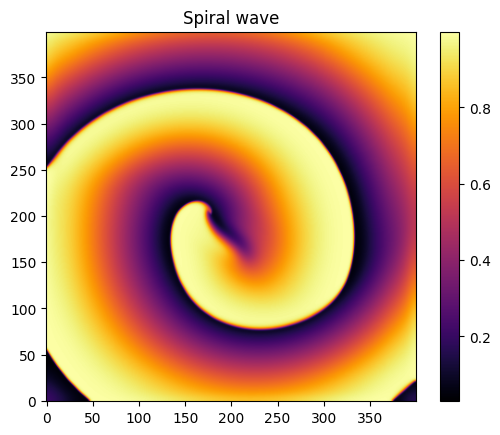

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import finitewave as fw

n = 400
tissue = fw.CardiacTissue([n, n], dr=0.5)
tissue.mesh += (np.random.rand(*tissue.mesh.shape) < 0.).astype(tissue.mesh.dtype)

stim_prepacing = fw.StimSingleCell(dt=0.01)
stim_prepacing.add_stim(n_beats=100, cycle_length=300, curr_value=1., duration=1.)

model = fw.FentonKarma()
model.prepacing(stim_prepacing, history=True)

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoord(0, 1, 0, n, 0, n//2))
stim_sequence.add_stim(fw.StimVoltageCoord(215, 1, 0, 3*n//4, n//2-10, n//2+10))

frame_tracker = fw.FrameTracker(aggregate=True, step=50, keep_shape=True, start_time=1000)
tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(frame_tracker)

simulation = fw.CardiacSimulation(dt=0.02, t_max=3000, backend="mlx")
simulation.cardiac_tissue = tissue
simulation.cardiac_model = model
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence
simulation.run()

u = simulation.cardiac_model.output("u")
u_old = simulation.solver.u.reshape(u.shape)


plt.imshow(u, cmap="inferno", origin="lower")
plt.colorbar()
plt.title("Spiral wave")
plt.show()

## Step 2: Locating the Wavefront with Isopotential Contours

After simulating the spiral wave, the next task is to identify the precise boundary of the wave. In excitable media, the wavefront is typically defined by the isopotential line—the points where the excitation variable `u` reaches exactly half of its maximum value ($u_{max}/2$).

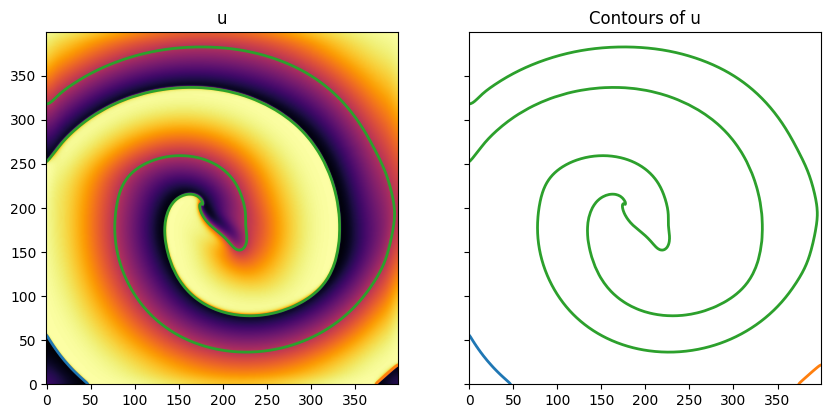

In [2]:
from skimage import measure


contours = measure.find_contours(u, level=0.5)

fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 5))

axs[0].imshow(u, cmap="inferno", origin="lower")
for contour in contours:
    axs[0].plot(contour[:, 1], contour[:, 0], linewidth=2)
    axs[1].plot(contour[:, 1], contour[:, 0], linewidth=2)

axs[1].set_aspect("equal")
axs[0].set_title("u")
axs[1].set_title("Contours of u")
plt.show()

## Step 3: Identifying the Wavefront using Gradient Magnitude

While the isopotential contour gives us the general shape of the spiral, it doesn't distinguish between the depolarizing front (where cells are rapidly exciting) and the repolarizing tail (where they are recovering).

To isolate the leading edge—the wavefront—we calculate the gradient of u. In excitable media, the front is characterized by the steepest spatial change in potential. We calculate the magnitude of the gradient:

$|\nabla u| = \sqrt{(\partial_x u) ^ 2 + (\partial_y u) ^ 2}$

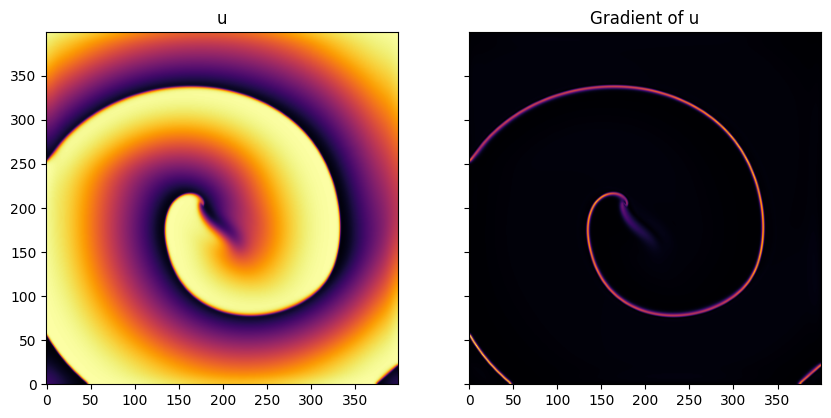

In [24]:
import numpy as np


def calc_gradient(u):
     u_gr = np.gradient(u)
     return np.sqrt(u_gr[0]**2 + u_gr[1]**2)

u_grad = calc_gradient(u)
fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 5))

axs[0].imshow(u, cmap="inferno", origin="lower")
axs[1].imshow(u_grad, cmap="inferno", origin="lower")

axs[1].set_aspect("equal")
axs[0].set_title("u")
axs[1].set_title("Gradient of u")
plt.show()

## Step 4: Selecting Isocontours with High Gradients
In this final refinement step, we combine our geometric data from Step 2 with the intensity data from Step 3. While we have many isopotential lines, only a portion of these lines represents the active depolarizing front of the spiral.  

By sampling the gradient magnitude along each detected contour, we can filter out the "slow" repolarizing tails and isolate the "fast" leading edges. This selection process is essential for pinpointing the spiral tip, as the tip is defined by the specific point where the high-gradient front meets the singularity.

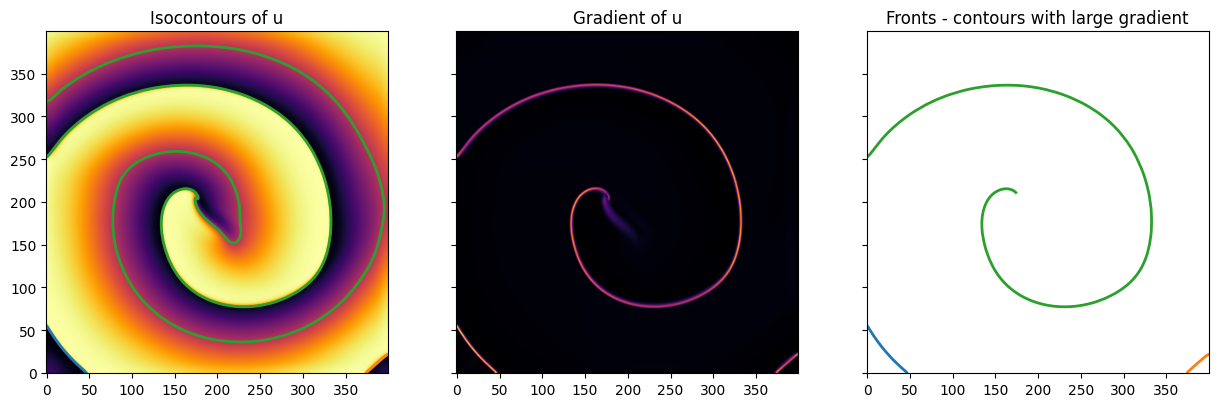

In [25]:
def is_large_gradient(contour, u_grad, threshold):
    grad_values = u_grad[contour[:, 0].astype(int),
                         contour[:, 1].astype(int)]
    return grad_values > threshold


def find_contours_with_large_gradient(contours, u_grad, grad_threshold):
    large_gradient_contours = []
    for contour in contours:
        front_mask = is_large_gradient(contour, u_grad, grad_threshold)
        contour = contour[front_mask]
        if len(contour) > 0:
            large_gradient_contours.append(contour)
    return large_gradient_contours


front_contours = find_contours_with_large_gradient(contours, u_grad, 0.15)

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize=(15, 5))

axs[0].imshow(u, cmap="inferno", origin="lower")
axs[1].imshow(u_grad, cmap="inferno", origin="lower")
for contour in contours:
    axs[0].plot(contour[:, 1], contour[:, 0], lw=2)

for contour in front_contours:
    axs[2].plot(contour[:, 1], contour[:, 0], lw=2)
    axs[2].set_aspect("equal")

axs[0].set_title("Isocontours of u")
axs[1].set_title("Gradient of u")
axs[2].set_title("Fronts - contours with large gradient")
plt.show()

## Step 4: Extracting Tip Coordinates and Cleaning Boundary Noise
The final step in detecting the spiral core involves identifying the endpoints of our filtered high-gradient wavefronts. In a spiral wave, the point where the wavefront simply "stops" in the middle of the medium is the spiral tip (or phase singularity).  

However, numerical simulations often produce contours that terminate at the edges of the simulation grid. To ensure we are tracking the actual spiral core and not a boundary artifact, we must:

Identify endpoints: Find the start and end coordinates of each high-gradient contour line.

Filter by proximity: Discard any points that fall within a certain distance (buffer zone) of the image boundaries.

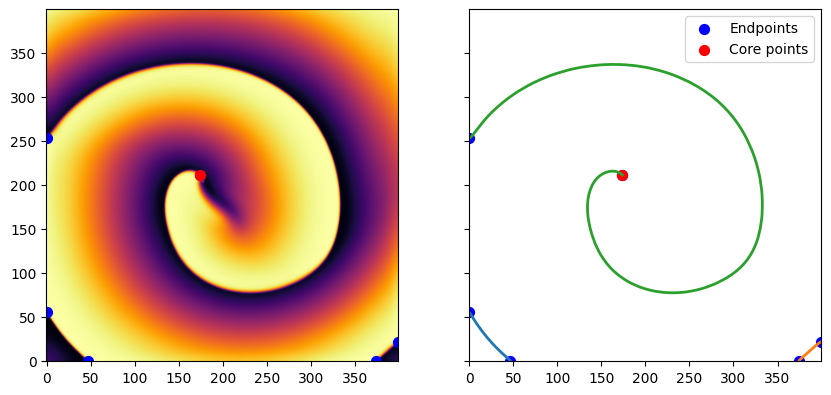

In [23]:
import numpy as np


def is_close_to_boundary(points, mesh, threshold=5):
    x = points[:, 0]
    y = points[:, 1]
    is_close = ((x < threshold) | (x > mesh.shape[0] - threshold) | 
                (y < threshold) | (y > mesh.shape[1] - threshold))
    return is_close


def find_front_endpoints(front_contours):
    endpoints = []
    for contour in front_contours:
        endpoints.append(contour[0])
        endpoints.append(contour[-1])
    return np.array(endpoints)


end_points = find_front_endpoints(front_contours)

core_points = end_points[~is_close_to_boundary(end_points, u)]

fig, axs = plt.subplots(1, 2, sharex=True, sharey=True, figsize=(10, 5))

axs[0].imshow(u, cmap="inferno", origin="lower")
axs[0].scatter(end_points[:, 1], end_points[:, 0], color="blue", s=50, label="Endpoints")
axs[0].scatter(core_points[:, 1], core_points[:, 0], color="red", s=50, label="Core points")

for contour in front_contours:
    axs[1].plot(contour[:, 1], contour[:, 0], lw=2)
axs[1].scatter(end_points[:, 1], end_points[:, 0], color="blue", s=50, label="Endpoints")
axs[1].scatter(core_points[:, 1], core_points[:, 0], color="red", s=50, label="Core points")
axs[1].set_aspect("equal")
axs[1].legend()
plt.show()

## Step 5: Detect Spiral Wave Cores Across the Time Series
With the detection logic finalized, we now wrap the algorithm into a loop to process the entire simulation dataset. This allows us to track the meandering trajectory of the spiral core over time. Analyzing the path of the core is essential for understanding the stability and dynamics of the excitable medium.

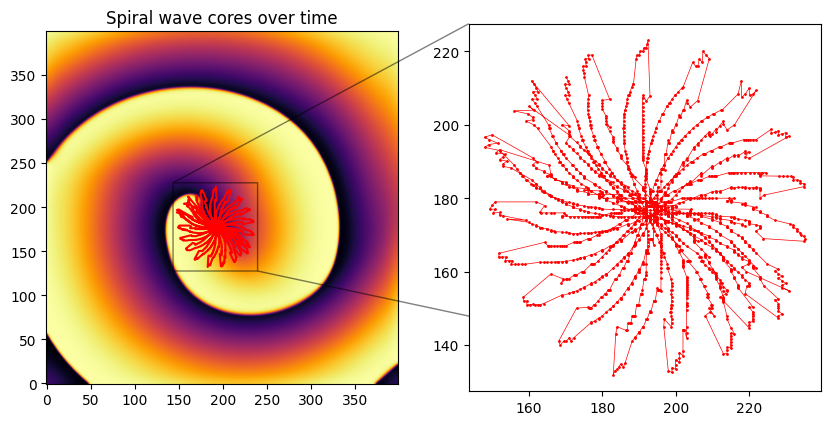

In [33]:
from skimage import measure


def find_sw_cores(frame, mesh, u_threshold=0.5, grad_threshold=0.2):
    contours = measure.find_contours(frame, level=u_threshold)
    u_grad = calc_gradient(frame)
    
    front_contours = find_contours_with_large_gradient(contours, u_grad, 
                                                       grad_threshold=grad_threshold)
    endpoints = find_front_endpoints(front_contours)
    if len(endpoints) == 0:
        return []
    core_points = endpoints[~is_close_to_boundary(endpoints, mesh)]
    return core_points


frames = frame_tracker.output
sw_cores = []
for frame in frames:
    end_points = find_sw_cores(frame, tissue.mesh)
    if len(end_points) > 0:
        sw_cores.append(end_points)

sw_cores = np.squeeze(sw_cores)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))

axs[0].imshow(frames[-1], cmap="inferno", origin="lower")
axs[0].plot(sw_cores[:, 1], sw_cores[:, 0], "r", label="Spiral wave cores")
axs[0].set_title("Spiral wave cores over time")
axs[1].plot(sw_cores[:, 1], sw_cores[:, 0], "r", label="Spiral wave cores",
            lw=0.5, marker="o", markersize=1)
axs[1].set_aspect("equal")

axs[0].indicate_inset_zoom(axs[1], edgecolor="black")
plt.show()